# ML configuration cookbook

A renderer decides what shape a source becomes, and that choice is not free: it
determines whether samples can be stacked into a batch, what happens when a
source is absent for a position and date, and how much of the native resolution
survives. Each recipe below states the tensor structure it produces, what it
does with empty data, and why its renderer and collator fit that structure.
Every recipe runs against the same pinned catalog revision and the same
published evaluation QuerySet loaded in the setup cells, so the recipes differ
only in their rendering configuration.

In [1]:
import os
import warnings
from io import BytesIO
from pathlib import Path

from IPython.display import Image, display

# Hub transfers report progress on stderr, which would otherwise be captured as
# notebook output and rendered as noise in the documentation.
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

# Warnings raised by the library are part of what these tutorials demonstrate,
# but Python's default format prefixes each one with the absolute path of the
# file that raised it, which is an artifact of the machine that built the docs.
def _format_warning(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _format_warning

def display_figure(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))

PATCH_SIZE_KM = 256          # the published patch size
REQUESTED_ROWS = 4
SEED = 7

# Draw records are notebook output, not cached data; they land beside the notebook.
DRAW_DIR = Path("draws")
DRAW_DIR.mkdir(exist_ok=True)

In [2]:
from ocean_taco import CatalogConfig, QuerySet
from ocean_taco.retrieve import load_hf_dataset

config = CatalogConfig()
catalog = load_hf_dataset(config)
queryset = QuerySet.from_hub(PATCH_SIZE_KM, "eval")
print(f"queryset_id={queryset.queryset_id}; kind={queryset.header['kind']}; positions={len(queryset.positions)}; dates={len(queryset.dates)}")

queryset_id=2b55f024f45630d5a81546832a108ed99648c4d7b5024d79a21b1f0851ef4f18; kind=eval; positions=6027; dates=858


## The row every recipe uses

Each recipe below renders the same drawn row, so the differences between them
come from the rendering configuration and nothing else. The helper prints the
tensor structure a configuration produces, which is the thing worth comparing:
shapes, masks, and whether the source was available at all.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from ocean_taco import GeoBox, QueryFilter, draw_queryset, select_queryset
from ocean_taco.render import Native, Points, Resample, VectorPair
from ocean_taco.torch import OceanTACODataset

recipe_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                            record_path=DRAW_DIR / "cookbook-draw.json",
                            query_filter=QueryFilter(box=GeoBox(-80, -30, 10, 45)))
row = recipe_draw.rows[0]
print(f"row: ({row['centre_lon']:.2f}, {row['centre_lat']:.2f}) on {row['anchor_time'][:10]}")

def render(sources):
    # Render the shared row under one configuration and report what came back.
    sample = OceanTACODataset(queries=recipe_draw, sources=sources, catalog_config=config)[0]
    for token in sources:
        record, available = sample[token], sample["availability"][token]
        shape = tuple(np.asarray(record["data"]).shape)
        valid = int(np.asarray(record["valid_mask"]).sum())
        print(f"  {token:10s} data={str(shape):18s} available={str(available):5s} valid_cells={valid}")
    return sample

def show_grid(axis, record, title, component=None):
    # Draw a rendered source, or state its absence rather than inventing pixels.
    data = np.asarray(record["data"])
    if data.shape[0] == 0:
        axis.text(.5, .5, "structurally absent for\nthis position and date", ha="center", va="center", transform=axis.transAxes)
        axis.set(title=f"{title}: shape {data.shape}", xticks=[], yticks=[])
        return
    image = data[0] if component is None else data[0][component]
    drawn = axis.imshow(image, origin="lower", cmap="turbo", aspect="auto")
    axis.set(title=f"{title}: shape {data.shape}", xlabel="x pixel", ylabel="y pixel")
    axis.figure.colorbar(drawn, ax=axis, shrink=.8)

row: (-55.35, 41.45) on 2025-03-11


## Fixed grids and multimodal fusion

Putting every source on one `Resample` grid is the conventional dense setup:
each source becomes `(T, H, W)` with the same `H` and `W`, so channels
concatenate and batches stack without padding. The cost is interpolation, paid
by every source whose native grid differs from the target.

Fusion is the same recipe with another source added. Adding `l3_swot` to two
complete L4 fields is the interesting case, because SWOT is sparse: it either
crosses this patch on this date or it does not, and the output below reports
which.

In [4]:
fixed = {"l4_sst": Resample((64, 64), .5), "l4_ssh": Resample((64, 64), .5)}
print("fixed grids:"); fixed_sample = render(fixed)
fusion = {**fixed, "l3_swot": Resample((64, 64), .5)}
print("with SWOT fused in:"); fusion_sample = render(fusion)

fixed grids:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
with SWOT fused in:


  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l4_ssh     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=2832


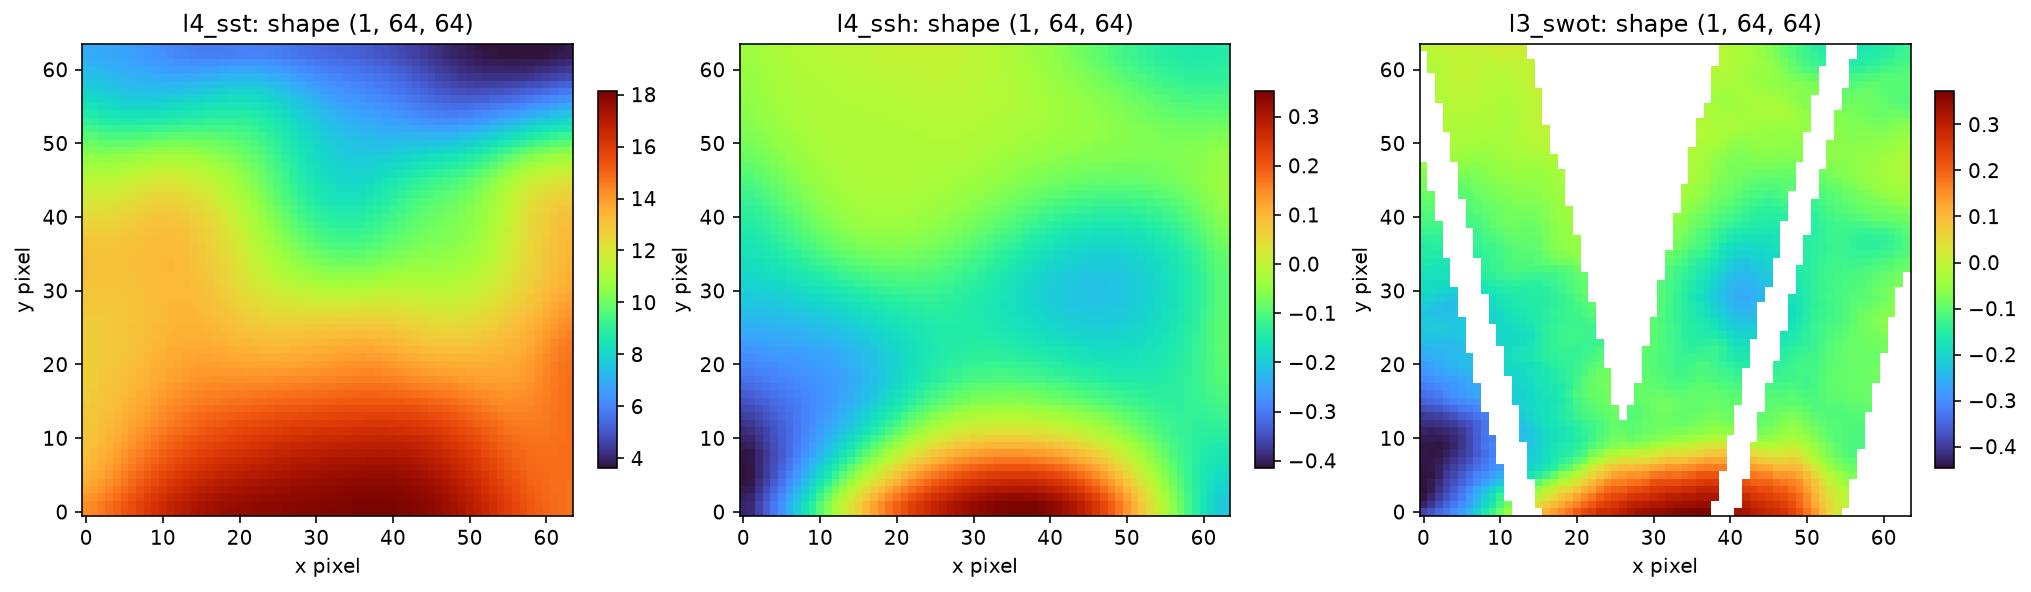

All three share one model-facing grid; their masks stay separate.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for axis, token in zip(axes, ("l4_sst", "l4_ssh", "l3_swot")):
    show_grid(axis, fusion_sample[token], token)
display_figure(fig)
print("All three share one model-facing grid; their masks stay separate.")

## Vector pairs

An eastward and a northward velocity component are not two independent
sources. They are one vector field, and rendering them separately would let
them disagree: a cell could end up with a valid `u` and an invalid `v`,
producing a direction that no measurement supports.

`VectorPair` renders both components as a unit. The result is `(T, 2, H, W)`
rather than two `(T, H, W)` entries, `valid_mask` describes cells where **both**
components have support, and `pair_available` is the sample-level Boolean. The
two components come from the same underlying asset, so they are also fetched
once rather than twice.

In [6]:
vectors = {"velocity": VectorPair(Resample((64, 64), .5))}
print("components:", vectors["velocity"].components)
velocity_sample = render(vectors)
velocity = velocity_sample["velocity"]
data = np.asarray(velocity["data"])
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    print(f"u range=[{np.nanmin(data[:, 0]):.3f}, {np.nanmax(data[:, 0]):.3f}] m/s")
    print(f"v range=[{np.nanmin(data[:, 1]):.3f}, {np.nanmax(data[:, 1]):.3f}] m/s")
    print(f"speed max={np.nanmax(speed):.3f} m/s; pair_available={bool(velocity['pair_available'])}")

components: ('glorys_uo', 'glorys_vo')


  velocity   data=(1, 2, 64, 64)     available=True  valid_cells=4096
u range=[-0.372, 1.359] m/s
v range=[-0.565, 1.038] m/s
speed max=1.685 m/s; pair_available=True


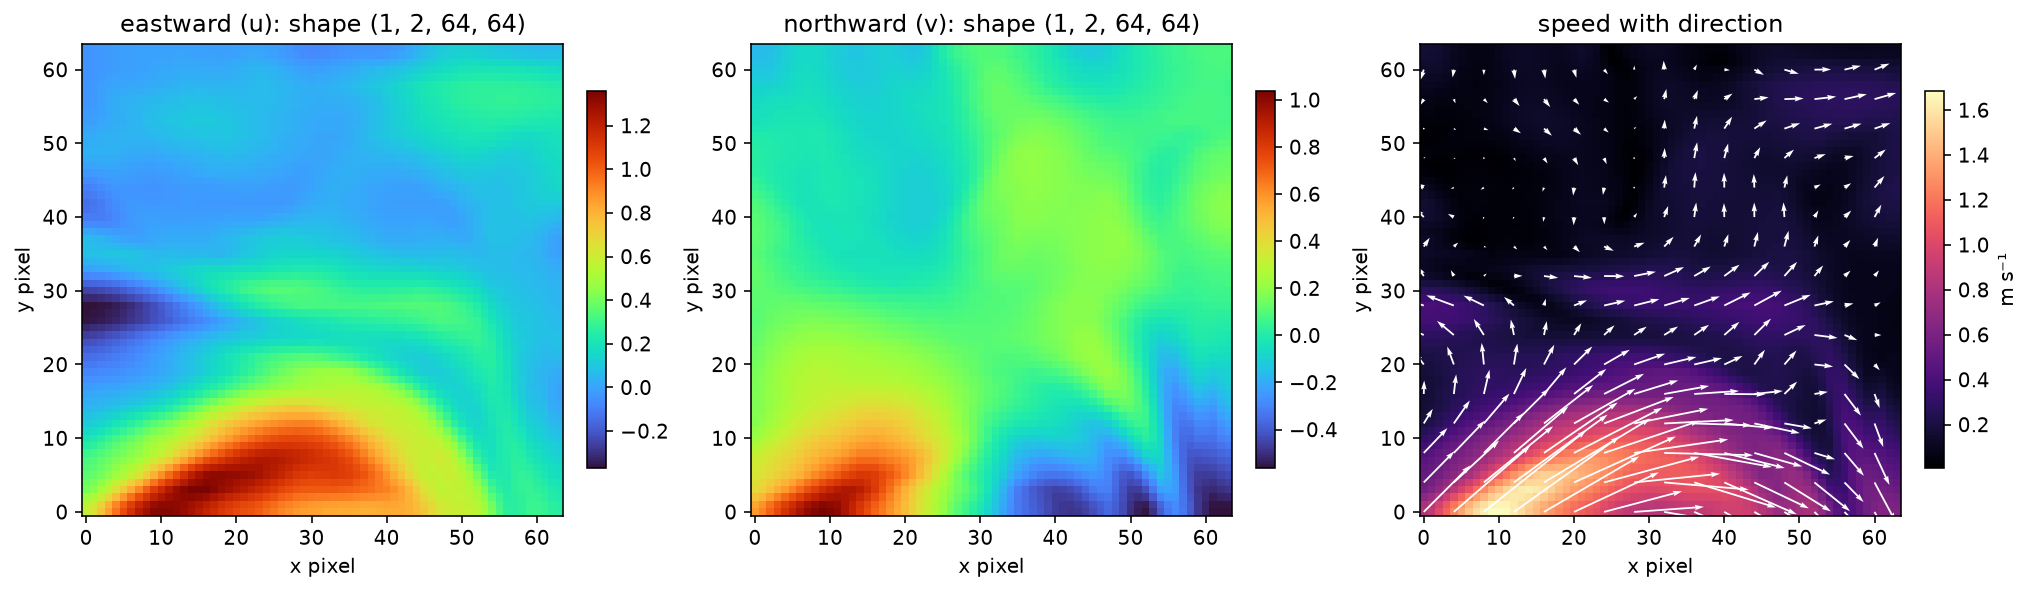

One shared mask governs both components, so every drawn arrow is supported by both.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
show_grid(axes[0], velocity, "eastward (u)", component=0)
show_grid(axes[1], velocity, "northward (v)", component=1)
data = np.asarray(velocity["data"])
if data.shape[0]:
    speed = np.hypot(data[0][0], data[0][1])
    drawn = axes[2].imshow(speed, origin="lower", cmap="magma", aspect="auto")
    step = max(1, speed.shape[0] // 16)
    grid_y, grid_x = np.mgrid[0:speed.shape[0]:step, 0:speed.shape[1]:step]
    axes[2].quiver(grid_x, grid_y, data[0][0][::step, ::step], data[0][1][::step, ::step], color="white", scale=6)
    axes[2].set(title="speed with direction", xlabel="x pixel", ylabel="y pixel")
    fig.colorbar(drawn, ax=axes[2], shrink=.8, label="m s⁻¹")
else:
    axes[2].text(.5, .5, "pair unavailable", ha="center", va="center", transform=axes[2].transAxes)
display_figure(fig)
print("One shared mask governs both components, so every drawn arrow is supported by both.")

## Sparse and dense sources together

Mixing a complete L4 analysis with a sparse L3 swath in one configuration is
the common multimodal case, and the thing to get right is that **a missing
SWOT cell is not an observation of zero**. It is a cell the satellite did not
sample. The masks carry that distinction; the values alone cannot, because zero
is a perfectly plausible sea-level anomaly.

A model that consumes both should therefore read `valid_mask` rather than
testing values against a sentinel, and a loss should be masked by it.

In [8]:
sparse_dense = {"l4_sst": Resample((64, 64), .5), "l3_swot": Resample((64, 64), .5)}
sparse_sample = render(sparse_dense)
for token in sparse_dense:
    mask = np.asarray(sparse_sample[token]["valid_mask"])
    if mask.size:
        print(f"{token:10s} valid fraction={mask.mean():.3f}")
print("A low valid fraction is evidence about sampling, not about the ocean.")

  l4_sst     data=(1, 64, 64)        available=True  valid_cells=4096
  l3_swot    data=(1, 64, 64)        available=True  valid_cells=2832
l4_sst     valid fraction=1.000
l3_swot    valid fraction=0.691
A low valid fraction is evidence about sampling, not about the ocean.


## Argo points

Argo is not a field. Each record is a float profile at its own position, so
`Points` returns ragged records with coordinates and pressures rather than a
grid, and the count varies from row to row. Zero points is a valid result and a
valid batch member: floats are sparse, and most patches on most days contain
none.

`variable` selects which measurement to expose, and `pres_range` limits the
depth band in decibars. Omitting it takes the shallowest usable level per
profile; the recipe below asks for the top 200 dbar so a full profile is
visible.

In [9]:
from ocean_taco.geobox import PatchSpec, PatchSize
# Argo is sparse against a 256 km patch: most drawn rows contain no floats at
# all, so this recipe names a patch that does, and then measures how common
# that is across the shared draw.
float_patch = PatchSpec(centre_lon=-47.1, centre_lat=21.9, patch_size=PatchSize(PATCH_SIZE_KM, "km"),
                        anchor_time="2025-04-23T00:00:00Z",
                        context_start_offset_days=0, context_end_offset_days=0)
points = {"argo": Points(variable="TEMP", pres_range=(0, 200))}
argo_sample = OceanTACODataset(queries=[float_patch], sources=points, catalog_config=config)[0]
record = argo_sample["argo"]
print("available:", argo_sample["availability"]["argo"])
for key in ("data", "lat", "lon", "pres"):
    if key in record:
        print(f"  {key:6s} shape={tuple(np.asarray(record[key]).shape)}")
print(f"{int(np.asarray(record['data']).size)} point records; the count is per patch and varies.")

available: True
  data   shape=(49,)
  lat    shape=(49,)
  lon    shape=(49,)
  pres   shape=(49,)
49 point records; the count is per patch and varies.


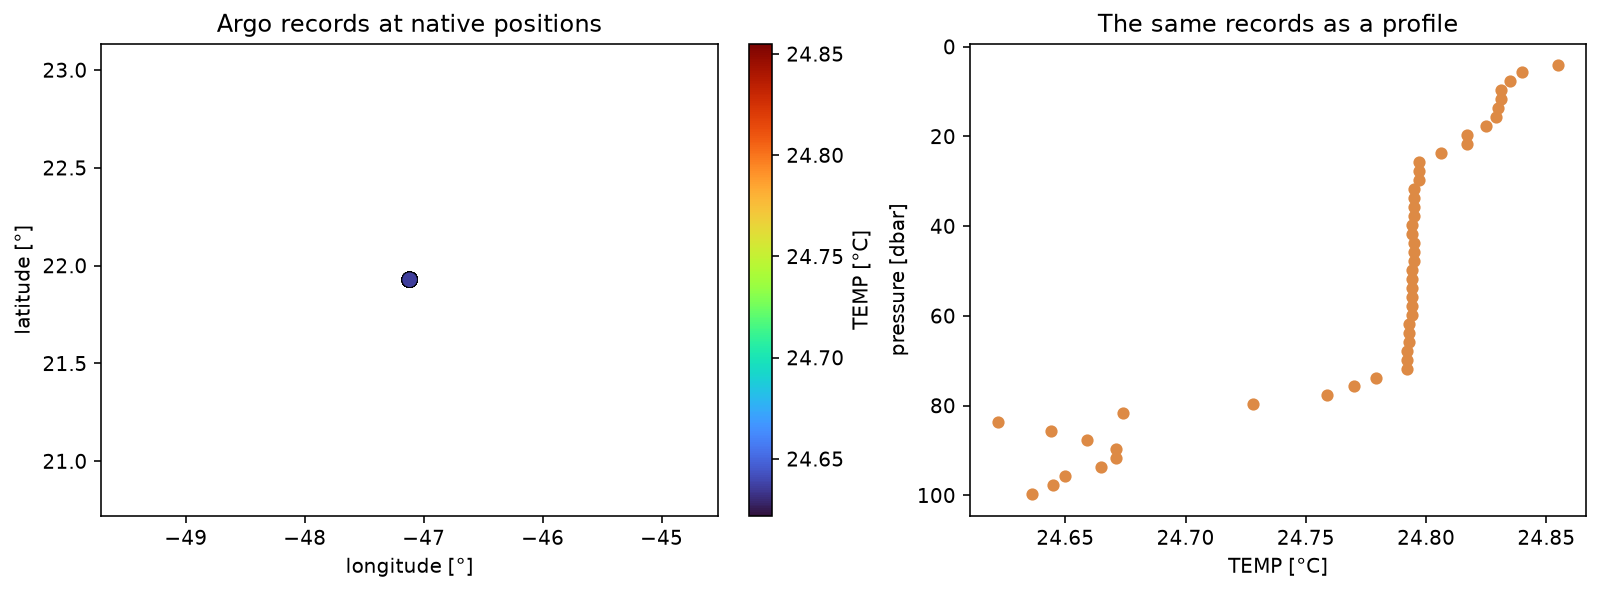

Points keep their own coordinates and pressures; nothing is rasterised onto a grid.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
lon, lat = np.asarray(record.get("lon", [])), np.asarray(record.get("lat", []))
values = np.asarray(record["data"]).reshape(-1)
if lon.size:
    drawn = axes[0].scatter(lon, lat, c=values[:lon.size], s=60, cmap="turbo", edgecolor="black", linewidth=.4)
    fig.colorbar(drawn, ax=axes[0], label="TEMP [°C]")
    pres = np.asarray(record["pres"]).reshape(-1)
    axes[1].scatter(values[:pres.size], pres, s=26, color="#dd8a45")
    axes[1].invert_yaxis()
    axes[1].set(title="The same records as a profile", xlabel="TEMP [°C]", ylabel="pressure [dbar]")
else:
    for axis in axes:
        axis.text(.5, .5, "no Argo profiles in this patch", ha="center", va="center", transform=axis.transAxes)
axes[0].set(title="Argo records at native positions", xlabel="longitude [°]", ylabel="latitude [°]")
display_figure(fig)
print("Points keep their own coordinates and pressures; nothing is rasterised onto a grid.")

In [11]:
# How often does a drawn patch contain floats at all?
survey = draw_queryset(queryset, requested_row_count=20, seed=29,
                       record_path=DRAW_DIR / "argo-survey-draw.json")
survey_dataset = OceanTACODataset(queries=survey, sources=points, catalog_config=config)
counts = [int(np.asarray(survey_dataset[index]["argo"]["data"]).size) for index in range(len(survey.rows))]
print(f"rows with at least one profile: {sum(count > 0 for count in counts)} of {len(counts)}")
print("Zero is the ordinary case at this patch size, and it is a valid batch member.")

rows with at least one profile: 1 of 20
Zero is the ordinary case at this patch size, and it is a valid batch member.


## Forecasting with two datasets

A forecasting setup needs the context window and the target to be separate
objects, so that a model consuming context cannot reach the target by
accident. The `QueryFilter` states the relation and the lead time; the two
datasets then differ only in their context offsets.

The output below is the check that matters: the two windows must not overlap.
If they do, the model can see its own target.

In [12]:
# One draw, so both datasets describe the same rows; only the offsets differ.
# Drawing twice would change which rows are eligible and silently compare
# different anchors.
forecast = QueryFilter(relation="forecast", target_lead_days=1,
                       context_start_offset_days=-1, context_end_offset_days=0)
forecast_draw = draw_queryset(queryset, requested_row_count=1, seed=29,
                              record_path=DRAW_DIR / "forecast-draw.json", query_filter=forecast)
source = {"l4_sst": Resample((64, 64), .5)}
lead = forecast.target_lead_days
target_row_maps = [
    {**row, "context_start_offset_days": lead, "context_end_offset_days": lead}
    for row in forecast_draw.rows
]
context_rows = OceanTACODataset(queries=forecast_draw, sources=source, catalog_config=config)
target_rows = OceanTACODataset(queries=target_row_maps, sources=source, catalog_config=config)
context_window = context_rows[0]["query"].context
target_window = target_rows[0]["query"].context
print(f"anchor: {forecast_draw.rows[0]['anchor_time'][:10]}")
print(f"context window: {context_window.start:%Y-%m-%d} .. {context_window.end:%Y-%m-%d}")
print(f"target  window: {target_window.start:%Y-%m-%d} .. {target_window.end:%Y-%m-%d}")
print(f"windows disjoint: {target_window.start > context_window.end}")

anchor: 2025-04-23
context window: 2025-04-22 .. 2025-04-23
target  window: 2025-04-24 .. 2025-04-24
windows disjoint: True


## Native shapes and bucketing

`Native()` returns the source's own grid, so nothing is interpolated and
nothing is invented — but shapes then vary from row to row, and varying shapes
cannot be stacked. `ShapeBucketSampler` solves that by grouping rows whose
native shapes already agree, so each batch is internally uniform without
padding.

Pass `shuffle=False` for a reproducible bucket ordering; it shuffles within
buckets by default, which makes a printed bucket list seed-dependent.

In [13]:
native_sample = render({"l3_swot": Native()})
resampled = np.asarray(fusion_sample["l3_swot"]["data"])
native = np.asarray(native_sample["l3_swot"]["data"])
print(f"native shape={native.shape}; resampled shape={resampled.shape}")
print("Native preserves the source grid exactly; Resample fixes the shape at the cost of interpolation.")

  l3_swot    data=(1, 128, 121)      available=True  valid_cells=10379
native shape=(1, 128, 121); resampled shape=(1, 64, 64)
Native preserves the source grid exactly; Resample fixes the shape at the cost of interpolation.


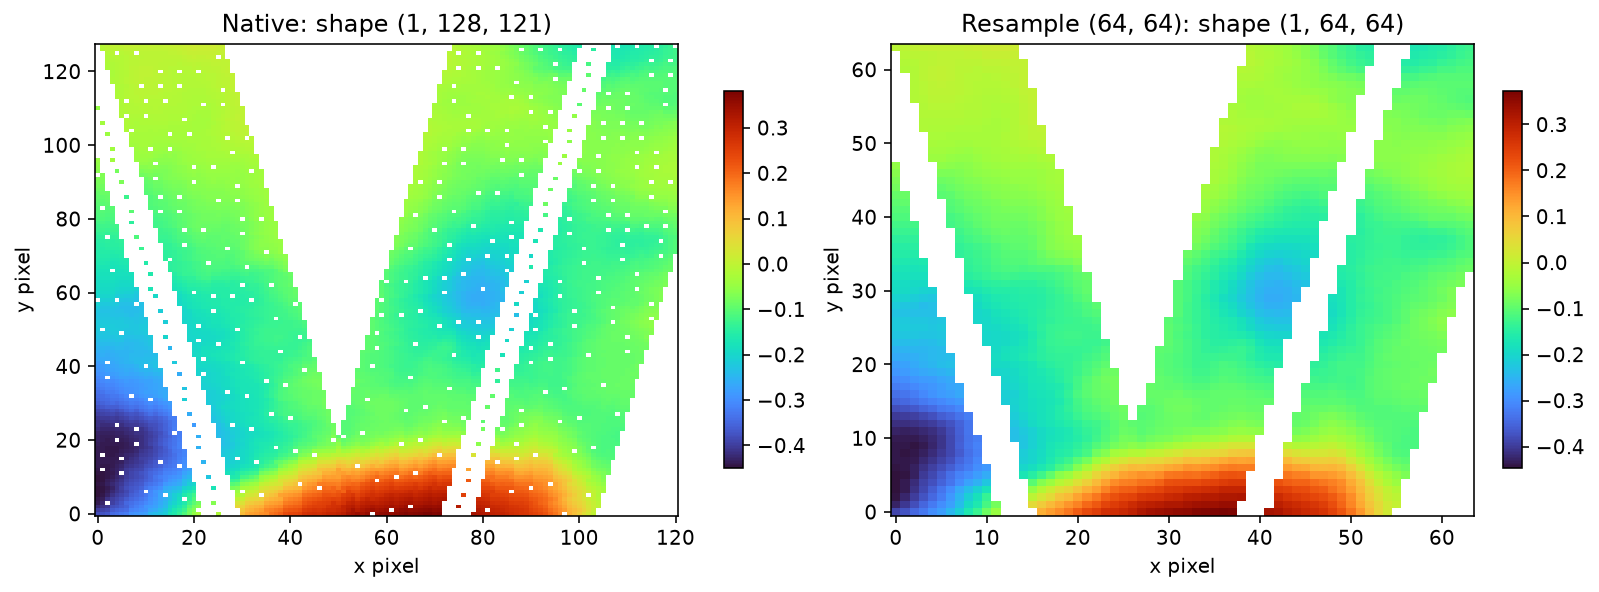

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
show_grid(axes[0], native_sample["l3_swot"], "Native")
show_grid(axes[1], fusion_sample["l3_swot"], "Resample (64, 64)")
display_figure(fig)

In [15]:
from ocean_taco.torch import ShapeBucketSampler
shapes = [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
sampler = ShapeBucketSampler(shapes, batch_size=2, seed=19, shuffle=False)
batches = list(sampler)
print("native shapes:", shapes)
print("batches:", batches)
for batch in batches:
    print("  ", [shapes[index] for index in batch], "-> uniform:", len({shapes[index] for index in batch}) == 1)

native shapes: [(32, 48), (32, 48), (40, 48), (40, 48), (32, 48)]
batches: [[0, 1], [4], [2, 3]]
   [(32, 48), (32, 48)] -> uniform: True
   [(32, 48)] -> uniform: True
   [(40, 48), (40, 48)] -> uniform: True


## Regional and antimeridian boxes

A regional box is an ordinary filter. A box crossing the antimeridian is not:
it is represented as two explicit segments, because a single interval from 170
to −170 is either empty or global depending on which comparison runs first.
Splitting it keeps every downstream test a simple interval comparison.

In [16]:
regional = GeoBox(-80, -30, 10, 45)
wrapped = GeoBox(170, -170, 10, 30, wraps_antimeridian=True)
print("regional segments:", len(regional.segments()))
for segment in wrapped.segments():
    print("  wrapped segment:", segment.to_dict())
print(f"regional population: {select_queryset(queryset, QueryFilter(box=regional)).count} pairs")

regional segments: 1
  wrapped segment: {'lon_min': 170, 'lon_max': 180.0, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
  wrapped segment: {'lon_min': -180.0, 'lon_max': -170, 'lat_min': 10, 'lat_max': 30, 'wraps_antimeridian': False}
regional population: 290862 pairs


## Normalisation

The loader returns decoded values in their recorded units and normalises
nothing, because normalisation is an experiment-level choice that has to be
recorded with the experiment. Apply it through `valid_mask`, so invalid cells
stay NaN rather than becoming a plausible-looking zero, and compute the
statistics once over the training population rather than per batch.

In [17]:
import torch
def normalise_valid(data, mask, mean, std):
    output = torch.full_like(data, float("nan"))
    output[mask] = (data[mask] - mean) / torch.as_tensor(std, dtype=data.dtype).clamp_min(1e-6)
    return output

# l3_swot is the informative case: its swath covers only part of the patch, so
# the mask actually excludes cells and the NaN behaviour is visible.
values, mask = fusion_sample["l3_swot"]["data"], fusion_sample["l3_swot"]["valid_mask"]
mean, std = values[mask].mean(), values[mask].std()
normalised = normalise_valid(values, mask, mean, std)
print(f"source mean={mean:.4f} std={std:.4f} over {int(mask.sum())} of {mask.numel()} cells")
print(f"normalised mean={normalised[mask].mean():.3e} std={normalised[mask].std():.3f}")
print(f"{int((~mask).sum())} invalid cells, all still NaN: {bool(torch.isnan(normalised[~mask]).all())}")
# Zero-filling before averaging is the failure this guards against: it treats
# every unobserved cell as a measured zero.
filled = torch.nan_to_num(values, nan=0.0)
print(f"masked mean={mean:.4f} vs zero-filled mean={filled.mean():.4f}")
print("Leakage control is separate: disjoint filters, temporal guard bands, and persisted draw records.")

source mean=-0.0930 std=0.1220 over 2832 of 4096 cells
normalised mean=1.604e-08 std=1.000
1264 invalid cells, all still NaN: True
masked mean=-0.0930 vs zero-filled mean=-0.0643
Leakage control is separate: disjoint filters, temporal guard bands, and persisted draw records.


## Geometry of the selections used above

The regional box and the antimeridian box drawn together, so the two-segment
representation is visible as geometry rather than only as a printed dict.

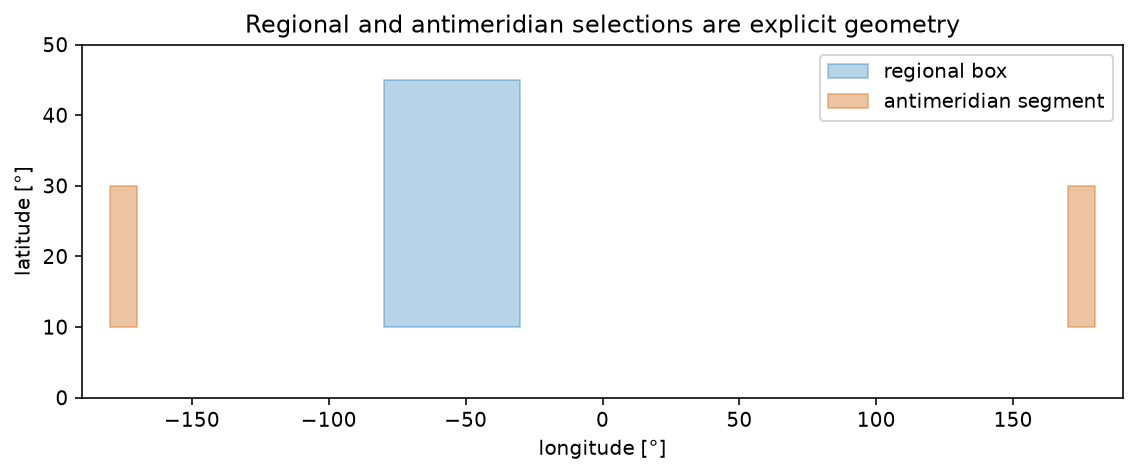

The wrapped box is two rectangles, which is what every downstream interval test sees.


In [18]:
fig, axis = plt.subplots(figsize=(8, 3.4))
axis.fill_between([-80, -30], 10, 45, alpha=.35, color="#3182bd", label="regional box")
for segment in wrapped.segments():
    axis.fill_between([segment.lon_min, segment.lon_max], segment.lat_min, segment.lat_max, alpha=.5, color="#dd8a45", label="antimeridian segment")
axis.set(xlim=(-190, 190), ylim=(0, 50), xlabel="longitude [°]", ylabel="latitude [°]",
         title="Regional and antimeridian selections are explicit geometry")
handles, labels = axis.get_legend_handles_labels()
axis.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())
fig.tight_layout()
display_figure(fig)
print("The wrapped box is two rectangles, which is what every downstream interval test sees.")